In [3]:
# Imports, Configuration and loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential  # type: ignore
from tensorflow.keras.layers import Dense, Dropout # type: ignore
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, recall_score
import shap 

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

# Data Loading 
FILE_PATH = 'D:\AIPractical\BreastCancer/Breast_cancer_dataset.csv' 
df = pd.read_csv(FILE_PATH)

# Remove nan column and prevent data from emptying
df.drop(df.columns[-1], axis=1, inplace=True)

print("\n--- Diagnostic Check ---")
print(f"Data Loaded and Empty Column Dropped. New shape: {df.shape}") 
print(f"The first column we must remove is: {df.columns[0]}")
print("\nFirst 3 rows of data:")
print(df.head(3))

<>:21: SyntaxWarning: invalid escape sequence '\A'
<>:21: SyntaxWarning: invalid escape sequence '\A'
C:\Users\heman\AppData\Local\Temp\ipykernel_25872\2249132730.py:21: SyntaxWarning: invalid escape sequence '\A'
  FILE_PATH = 'D:\AIPractical\BreastCancer/Breast_cancer_dataset.csv'



--- Diagnostic Check ---
Data Loaded and Empty Column Dropped. New shape: (569, 32)
The first column we must remove is: id

First 3 rows of data:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38           122.8     1001.0   
1    842517         M        20.57         17.77           132.9     1326.0   
2  84300903         M        19.69         21.25           130.0     1203.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   

   symmetry_mean  fractal_dimension_mean  radius_se  texture_se  perimeter_se  \
0         0.2419                 0.07871     1.0950      0.9053         8.589   
1         0.1812                 0.05667     0.5435      0.7339  

In [4]:
# Data initial Cleaning 
df.columns = df.columns.str.strip().str.lower()

df.drop(df.columns[0], axis=1, inplace=True)

df.dropna(inplace=True)

# Encode target variable: M (Malignant) -> 1, B (Benign) -> 0
df['diagnosis'] = LabelEncoder().fit_transform(df['diagnosis'])

X = df.drop('diagnosis', axis=1) # Features
y = df['diagnosis']             # Target

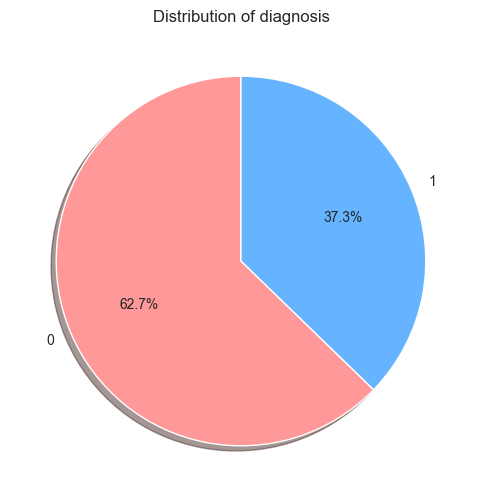

In [5]:
# Visualizing class distribution
cols_to_plot = df.select_dtypes(include=['object', 'category']).columns.tolist()

if 'diagnosis' not in cols_to_plot:
    cols_to_plot.append('diagnosis')

plt.figure(figsize=(6, 6))

# Plotting the first available categorical column 
df[cols_to_plot[0]].value_counts().plot.pie(
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ff9999','#66b3ff'],
    shadow=True
)

plt.title(f'Distribution of {cols_to_plot[0]}')
plt.ylabel('') 
plt.show()

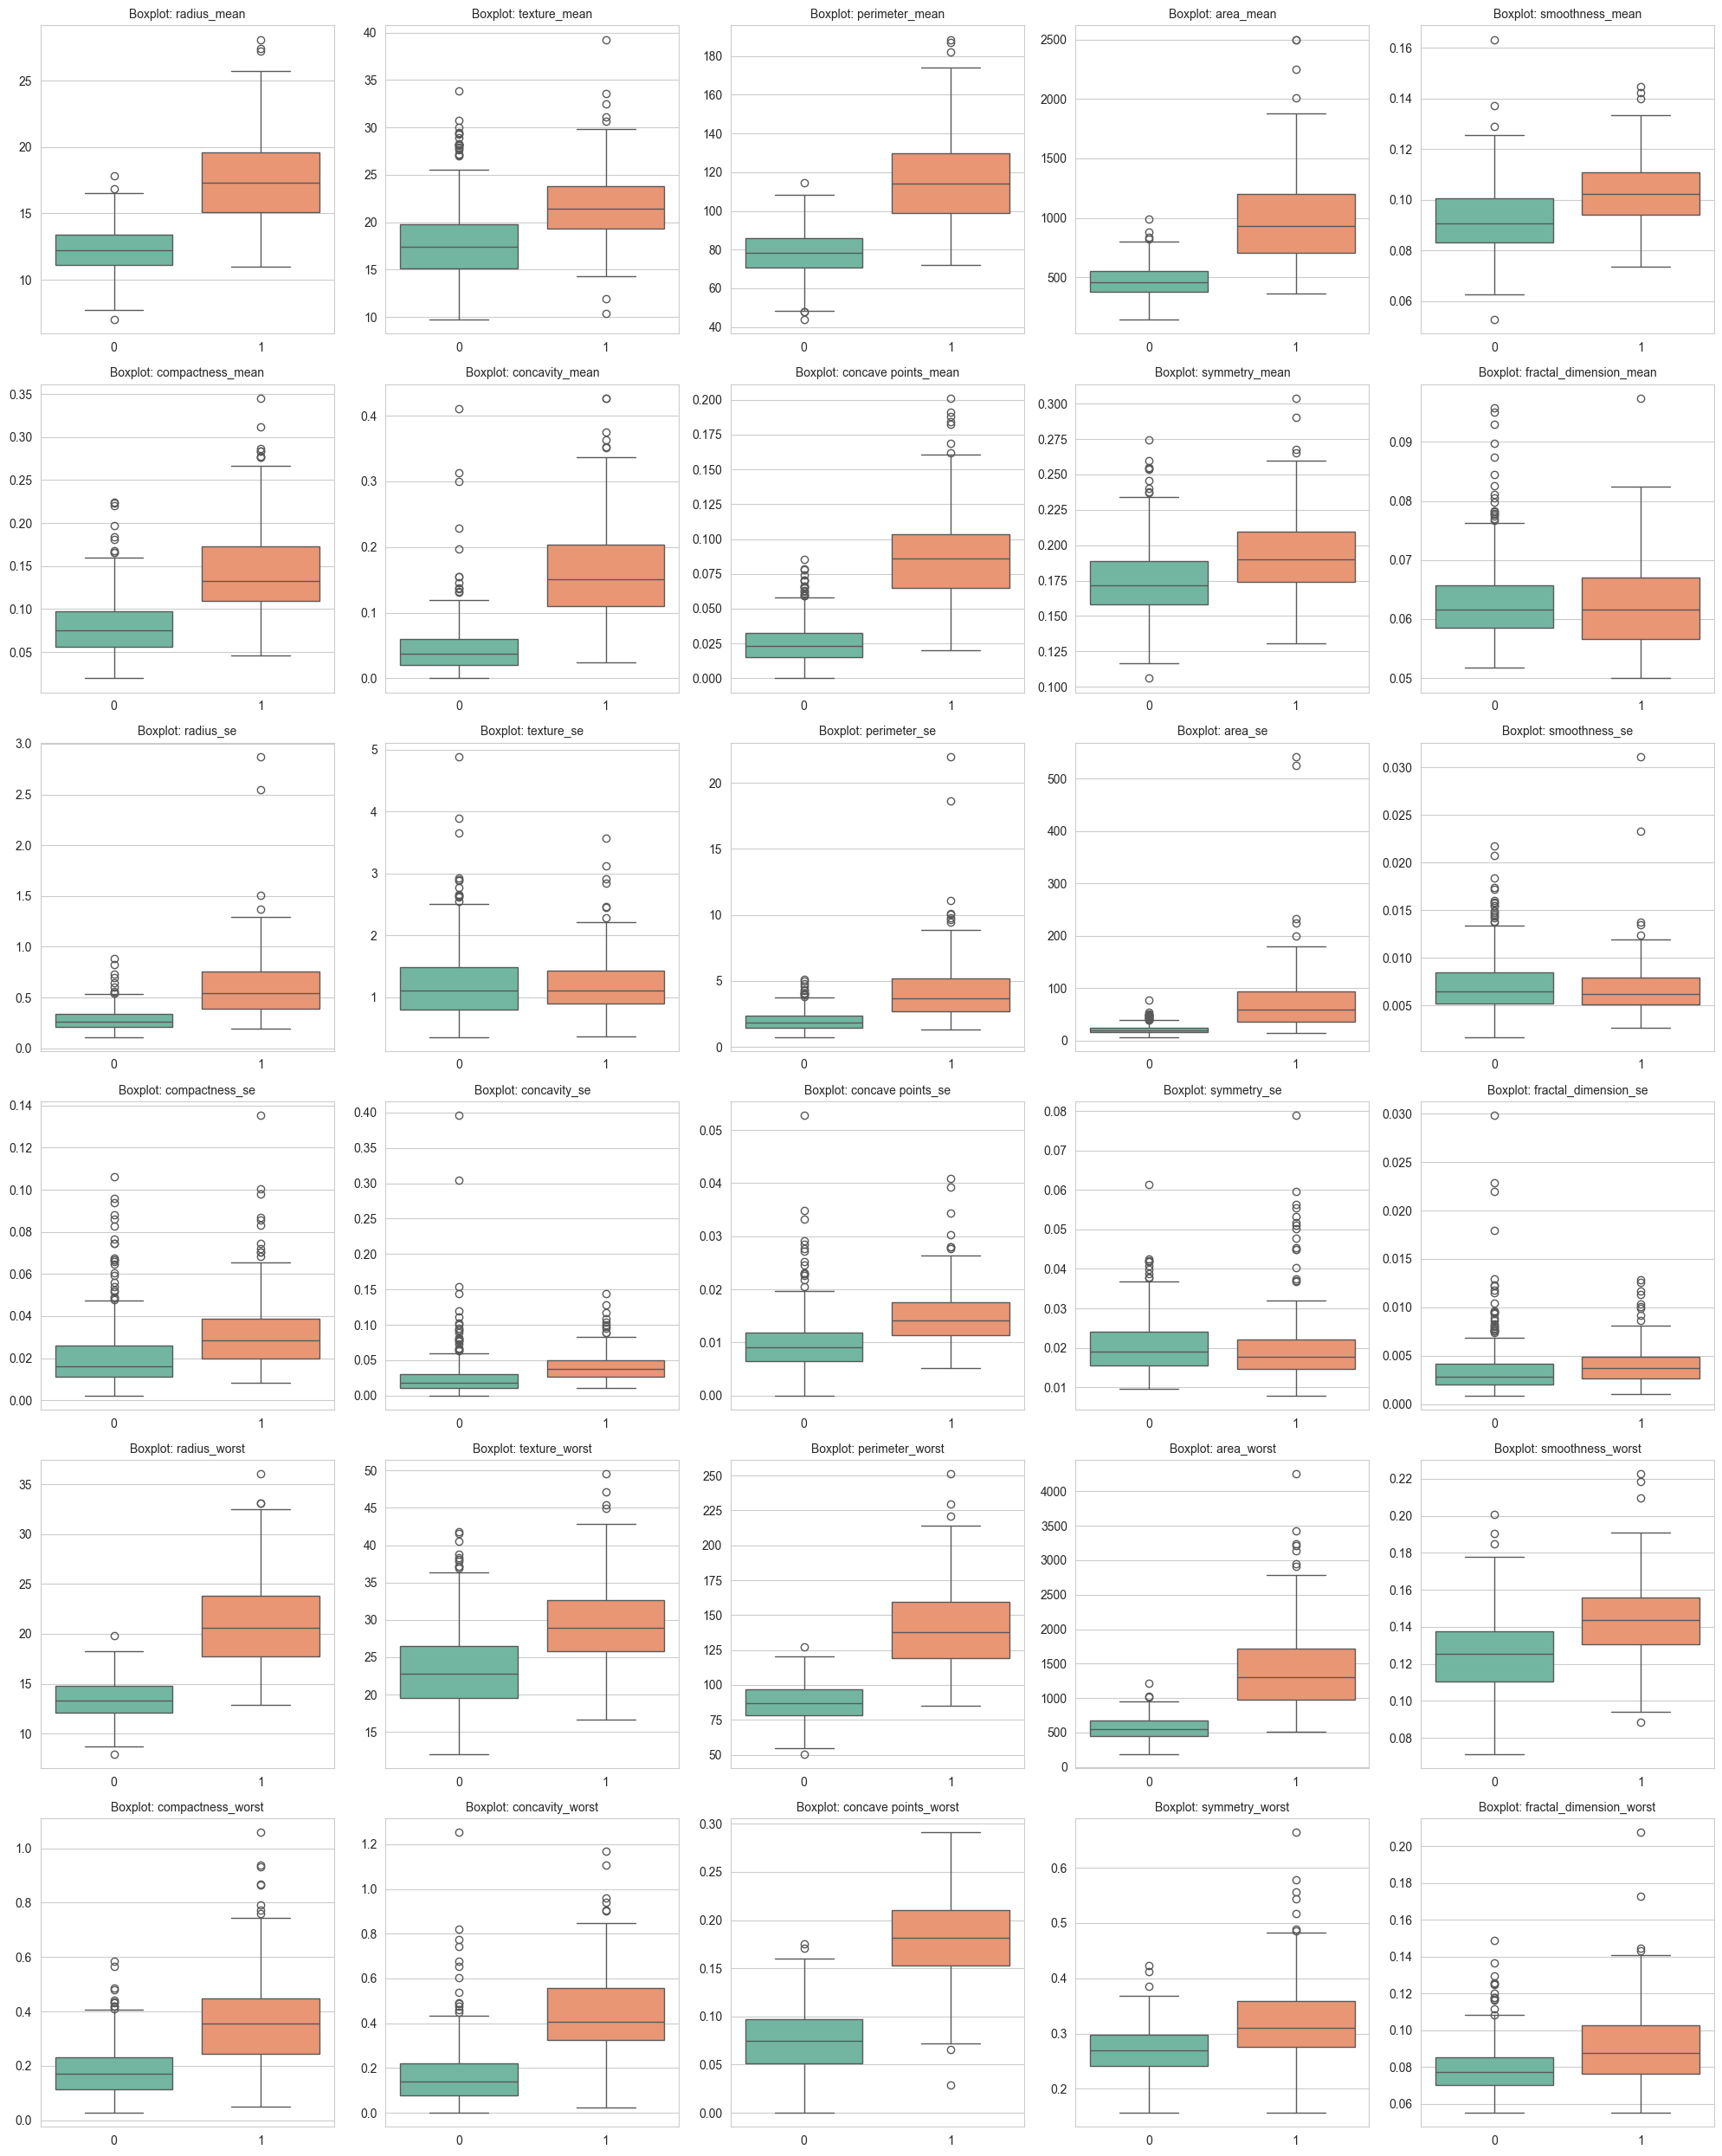

In [6]:
# 'diagnosis' is your target column (M/B)
features = df.columns.drop('diagnosis')
# Set the style
sns.set_style("whitegrid")
# Create a figure with a grid 
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 25))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x='diagnosis', y=col, data=df, ax=axes[i], hue='diagnosis', palette='Set2', legend=False)
    axes[i].set_title(f'Boxplot: {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
plt.tight_layout()
plt.show()

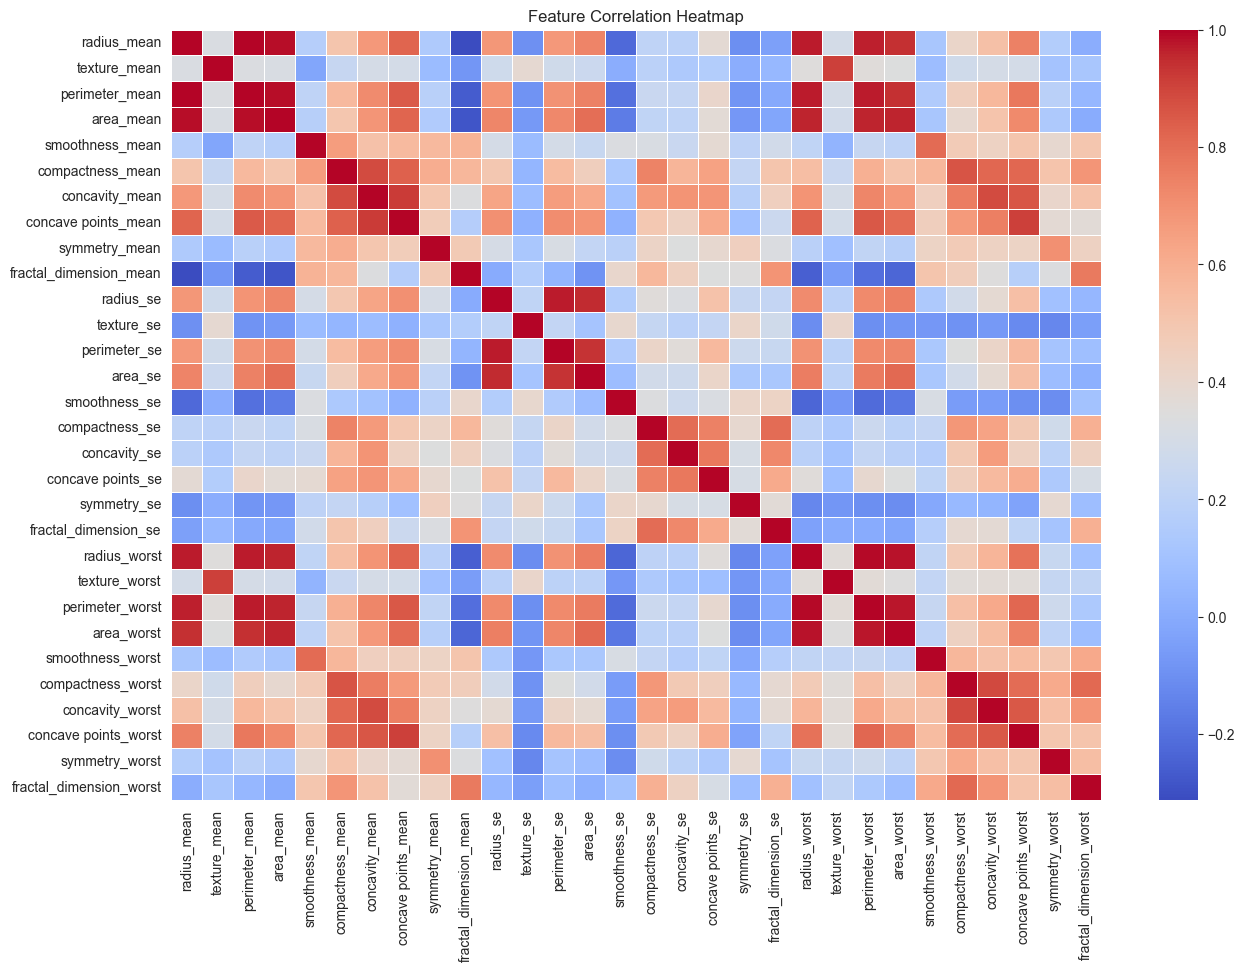

In [7]:
# Correlation Heatmap
plt.figure(figsize=(15, 10))
# Calculate correlation matrix
corr = X.corr() 
# Plot heatmap
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [8]:
# Create correlation matrix
corr_matrix = df.drop('diagnosis', axis=1).corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print(f"Features to be dropped: {to_drop}")

# Drop features 
df_reduced = df.drop(columns=to_drop)

print(f"Original feature count: {df.shape[1]}")
print(f"Reduced feature count: {df_reduced.shape[1]}")

Features to be dropped: ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']
Original feature count: 31
Reduced feature count: 21


In [9]:
# Train-Test Split (80/20) with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data split. Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# Feature Scaling (Crucial for SVC and Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

Data split. Training samples: 455, Test samples: 114


In [10]:
# Fitting logistic regression to the training set
classifier = LogisticRegression(random_state=0)
#classifier=svm.SVC(gamma='auto')
classifier.fit(X_train, y_train)

C:\Users\heman\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=0)

In [11]:
# Optimized Support Vector Machine (SVC) 

param_grid_svc = {'C': [0.1, 1, 10], 'gamma': [0.1, 0.01, 0.001], 'kernel': ['rbf']}

# GridSearchCV optimization is scored based on 'recall' (Malignant Recall)
grid_search_svc = GridSearchCV(SVC(probability=True, random_state=42),
                               param_grid_svc,
                               refit=True, verbose=0, cv=5, scoring='recall')
grid_search_svc.fit(X_train_scaled_df, y_train)

best_svc = grid_search_svc.best_estimator_
y_pred_svc = best_svc.predict(X_test_scaled_df)
print(f"Best SVC Parameters: {grid_search_svc.best_params_}")

Best SVC Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [12]:
# Optimized Random Forest Classifier 
print("\n--- Training Random Forest with Hyperparameter Tuning ---")

# Grid Search (Hyperparameter Tuning) 
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_leaf': [2, 4]}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                              param_grid_rf,
                              refit=True, verbose=0, cv=5, scoring='recall')
grid_search_rf.fit(X_train, y_train) 

best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test) 
print(f"Best Random Forest Parameters: {grid_search_rf.best_params_}")

# Cross-Validation Check for Final Model Robustness
from sklearn.model_selection import cross_val_score
rf_cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='recall')
print(f"RF 5-Fold Cross-Validation Recall: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")


--- Training Random Forest with Hyperparameter Tuning ---
Best Random Forest Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 100}
RF 5-Fold Cross-Validation Recall: 0.9297 (+/- 0.0439)


Model 'rf' has been trained with BALANCED weights.


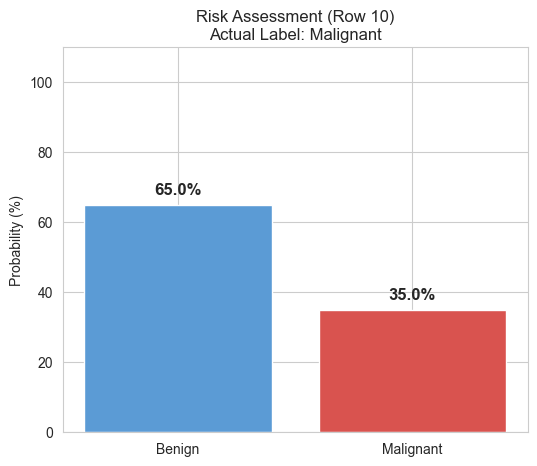

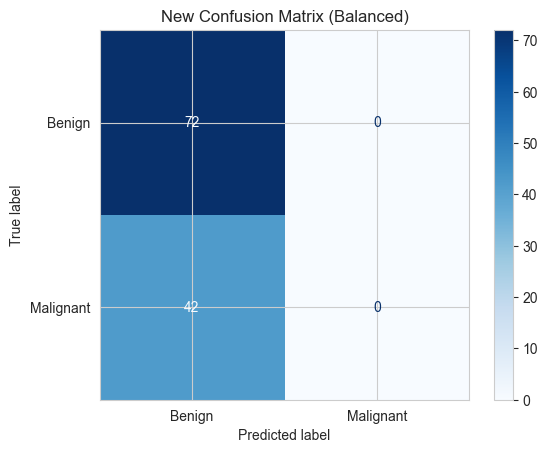

In [13]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#STEP 1: TRAIN THE BALANCED MODEL
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train) 

print("Model 'rf' has been trained with BALANCED weights.")

# STEP 2: PREDICTION & VISUALIZATION 

# Select a row to test (Row 10 was the borderline case we found earlier)
test_row_index = 10 
random_df = X_test_scaled_df.iloc[[test_row_index]] 

if hasattr(rf, "predict_proba"):
    proba = rf.predict_proba(random_df)[0]
    benign_percent = proba[0] * 100
    malignant_percent = proba[1] * 100
    
    # Check the actual label for the plot title
    actual = y_test.iloc[test_row_index]
    status = "Malignant" if actual == 1 else "Benign"
    
    # Visualization
    labels = ['Benign', 'Malignant']
    values = [benign_percent, malignant_percent]
    colors = ['#5b9bd5', '#d9534f']

    plt.figure(figsize=(6, 5))
    bars = plt.bar(labels, values, color=colors)
    plt.ylim(0, 110)
    plt.ylabel('Probability (%)')
    plt.title(f'Risk Assessment (Row {test_row_index})\nActual Label: {status}')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 2, 
                 f"{height:.1f}%", ha='center', va='bottom', 
                 fontsize=12, fontweight='bold')
    plt.show()

# --- STEP 3: RE-CHECK THE CONFUSION MATRIX ---
y_pred = rf.predict(X_test_scaled_df)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title("New Confusion Matrix (Balanced)")
plt.show()

In [14]:
# Deep Neural Network (Keras/TensorFlow) 
print("\n--- Training Keras Deep Neural Network ---")

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)), 
    Dropout(0.5), 
    Dense(64, activation='relu'), 
    Dropout(0.3), 
    Dense(1, activation='sigmoid') 
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['Recall'])

# Fit the model using scaled data
history = model.fit(X_train_scaled, y_train,
                    epochs=50, batch_size=32, validation_split=0.1, verbose=0)

# Evaluate the model on test data
loss, recall_keras = model.evaluate(X_test_scaled, y_test, verbose=0)
y_prob_keras = model.predict(X_test_scaled).flatten()
y_pred_keras = (y_prob_keras > 0.5).astype(int) 

print("Keras DNN Trained.")
print(f"Keras Test Recall: {recall_keras:.4f}")


--- Training Keras Deep Neural Network ---


C:\Users\heman\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Keras DNN Trained.
Keras Test Recall: 0.9286


In [15]:
#  Comparative Model Evaluation (Results Section Data)

def get_evaluation_metrics(model_name, y_true, y_pred):
    """Prints the classification report and returns key metrics."""
    print(f"\n===== Performance Metrics for {model_name} =====")
    report = classification_report(y_true, y_pred, target_names=['Benign (B)', 'Malignant (M)'], output_dict=True)
    print(classification_report(y_true, y_pred, target_names=['Benign (B)', 'Malignant (M)']))
    
    # Extracting the key metrics from the Malignant (M) class
    metrics = {
        'Recall': report['Malignant (M)']['recall'],
        'Precision': report['Malignant (M)']['precision'],
        'F1-Score': report['Malignant (M)']['f1-score'],
        'Accuracy': report['accuracy']}
    print(f"*** Key Metric: Malignant Recall (Sensitivity): {metrics['Recall']:.4f} ***")
    return metrics
# Evaluate and collect results
metrics_svc = get_evaluation_metrics("SVC (Optimized)", y_test, y_pred_svc)
metrics_rf = get_evaluation_metrics("Random Forest (Optimized)", y_test, y_pred_rf)
metrics_keras = get_evaluation_metrics("Keras DNN", y_test, y_pred_keras) 

# Create a summary table for the report
results_summary = pd.DataFrame({
    'Model': ['SVC', 'Random Forest', 'Keras DNN'],
    'Recall': [metrics_svc['Recall'], metrics_rf['Recall'], metrics_keras['Recall']],
    'Precision': [metrics_svc['Precision'], metrics_rf['Precision'], metrics_keras['Precision']],
    'F1-Score': [metrics_svc['F1-Score'], metrics_rf['F1-Score'], metrics_keras['F1-Score']],
    'Accuracy': [metrics_svc['Accuracy'], metrics_rf['Accuracy'], metrics_keras['Accuracy']],
}).sort_values(by='Recall', ascending=False).set_index('Model') # Sort by the key metric: Recall

print("\n--- Overall Model Comparison (Prioritized on Malignant Recall) ---")
print(results_summary)


===== Performance Metrics for SVC (Optimized) =====
               precision    recall  f1-score   support

   Benign (B)       0.97      0.96      0.97        72
Malignant (M)       0.93      0.95      0.94        42

     accuracy                           0.96       114
    macro avg       0.95      0.96      0.95       114
 weighted avg       0.96      0.96      0.96       114

*** Key Metric: Malignant Recall (Sensitivity): 0.9524 ***

===== Performance Metrics for Random Forest (Optimized) =====
               precision    recall  f1-score   support

   Benign (B)       0.96      1.00      0.98        72
Malignant (M)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114

*** Key Metric: Malignant Recall (Sensitivity): 0.9286 ***

===== Performance Metrics for Keras DNN =====
               precision    recall  f1-score   suppor

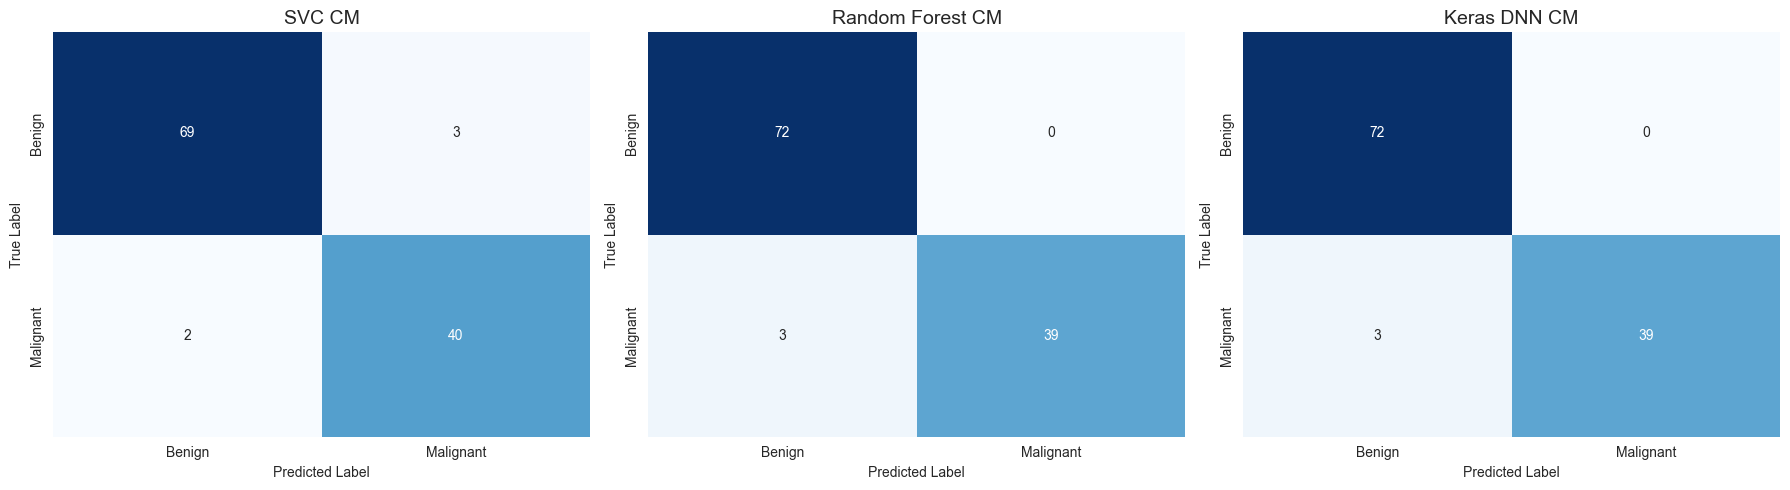

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


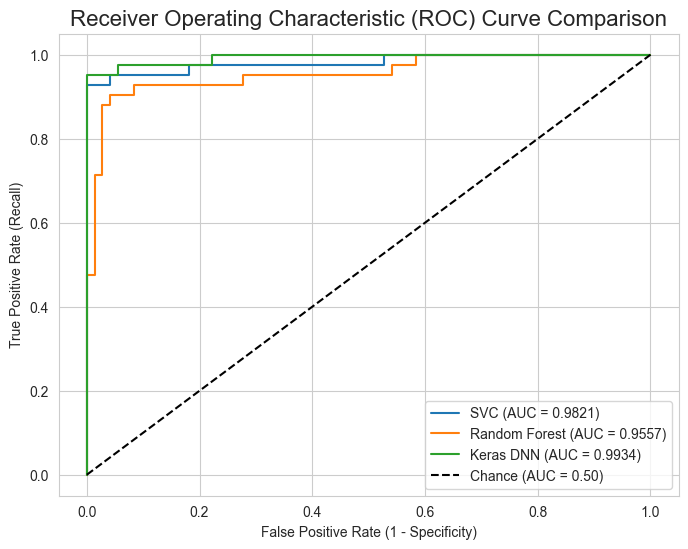

In [16]:
# Visualization of Results (Confusion Matrix and ROC Curve)

# Confusion Matrix Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ["SVC CM", "Random Forest CM", "Keras DNN CM"]

predictions = [y_pred_svc, y_pred_rf, y_pred_keras]

for ax, title, pred in zip(axes, titles, predictions):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

# ROC Curve Plot
plt.figure(figsize=(8, 6))

# list to include the Keras 'model'
models_and_preds = [
    (best_svc, X_test_scaled_df, 'SVC'),
    (best_rf, X_test_scaled_df, 'Random Forest'), # type: ignore
    (model, X_test_scaled, 'Keras DNN') 
]

for ml_model, X_data, name in models_and_preds:
    if name == 'Keras DNN':
        y_prob = ml_model.predict(X_data).flatten()
    else:
        y_prob = ml_model.predict_proba(X_data)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=16)
plt.legend(loc='lower right')
plt.show()

In [17]:
#  SVM MODEL 

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create SVM classifier
svm_clf = SVC(kernel='rbf')
svm_clf = SVC(kernel='rbf', probability=True)

# Train
svm_clf.fit(X_train, y_train)

# Predict
y_pred_svm = svm_clf.predict(X_test)

#Probablity
y_pred_prob = svm_clf.predict_proba(X_test)[:, 1]

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("\nSVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("SVM Probability Predictions:\n", y_pred_prob)

SVM Accuracy: 0.9035087719298246

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93        72
           1       1.00      0.74      0.85        42

    accuracy                           0.90       114
   macro avg       0.93      0.87      0.89       114
weighted avg       0.92      0.90      0.90       114


SVM Confusion Matrix:
 [[72  0]
 [11 31]]
SVM Probability Predictions:
 [0.03358377 0.99999884 0.4164834  0.36445198 0.13168947 0.02186421
 0.18319379 0.30471391 0.03296557 0.03625172 0.68032745 0.02059163
 0.99999966 0.0364798  0.10280066 0.01945008 0.34765637 0.04636337
 0.06960558 0.03819679 0.02115926 0.02868252 0.99999958 0.99380961
 0.31114256 0.0210391  0.02320048 0.66139837 0.64737055 0.99999558
 0.99999981 0.17651011 0.99488683 0.99998382 0.09676961 0.24987384
 0.06262842 0.01816237 0.81528572 0.52851804 0.0207869  0.02200365
 0.18285346 0.02884451 0.02894277 0.6373999  0.04926819 0.34165529
 0

In [18]:
#  DECISION TREE MODEL 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Decision Tree classifier
dt_clf = DecisionTreeClassifier()

# Train
dt_clf.fit(X_train, y_train)

# Predict
y_pred_dt = dt_clf.predict(X_test)

#Probability
y_pred_prob_dt = dt_clf.predict_proba(X_test)[:, 1]

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nDecision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("\nDecision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Decision Tree Probability Predictions:\n", y_pred_prob_dt)

Decision Tree Accuracy: 0.9122807017543859

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93        72
           1       0.90      0.86      0.88        42

    accuracy                           0.91       114
   macro avg       0.91      0.90      0.90       114
weighted avg       0.91      0.91      0.91       114


Decision Tree Confusion Matrix:
 [[68  4]
 [ 6 36]]
Decision Tree Probability Predictions:
 [0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1.
 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1.
 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0.
 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1.]


<Figure size 700x500 with 0 Axes>

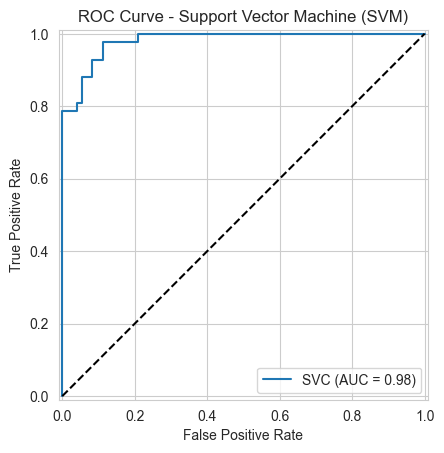

In [19]:
# ROC Curve: SVM 

plt.figure(figsize=(7,5))
RocCurveDisplay.from_estimator(svm_clf, X_test, y_test)
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - Support Vector Machine (SVM)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()

<Figure size 700x500 with 0 Axes>

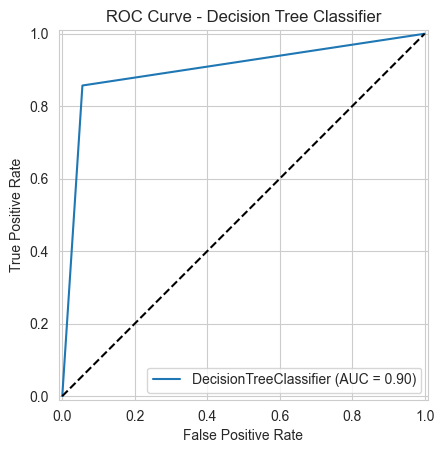

In [20]:
#  ROC Curve: Decision Tree 

plt.figure(figsize=(7,5))
RocCurveDisplay.from_estimator(dt_clf, X_test, y_test)
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve - Decision Tree Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()


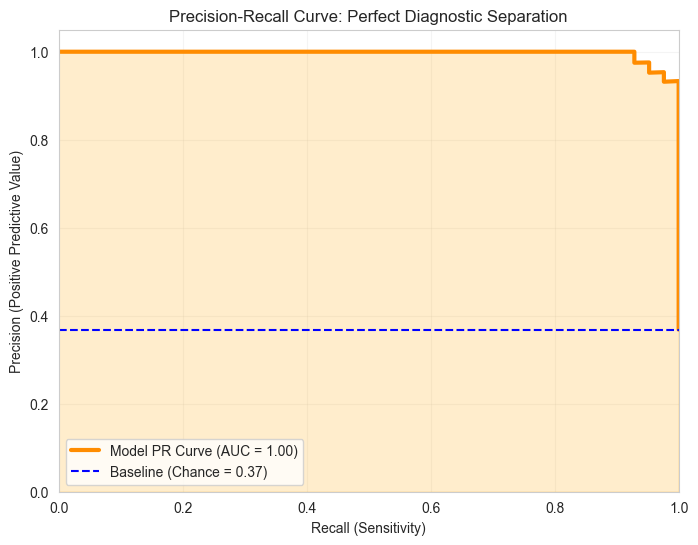

In [21]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_probs = best_rf.predict_proba(X_test)[:, 1] 
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))

# The Actual Model Line
plt.plot(recall, precision, color='darkorange', lw=3, label=f'Model PR Curve (AUC = {auc(recall, precision):.2f})')

# The Baseline (Chance) Line - Important for academic reports!
baseline = len(y_test[y_test==1]) / len(y_test)
plt.axhline(y=baseline, color='blue', linestyle='--', label=f'Baseline (Chance = {baseline:.2f})')

plt.fill_between(recall, precision, alpha=0.2, color='orange')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve: Perfect Diagnostic Separation')
plt.legend(loc="lower left")
plt.grid(alpha=0.2)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()


--- Generating SHAP Explanations for Keras Deep Neural Network ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Calculating SHAP values (this may take a few seconds)...


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

C:\Users\heman\AppData\Local\Temp\ipykernel_25872\3801797860.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled_df.iloc[:20].values, feature_names=X.columns, show=False)


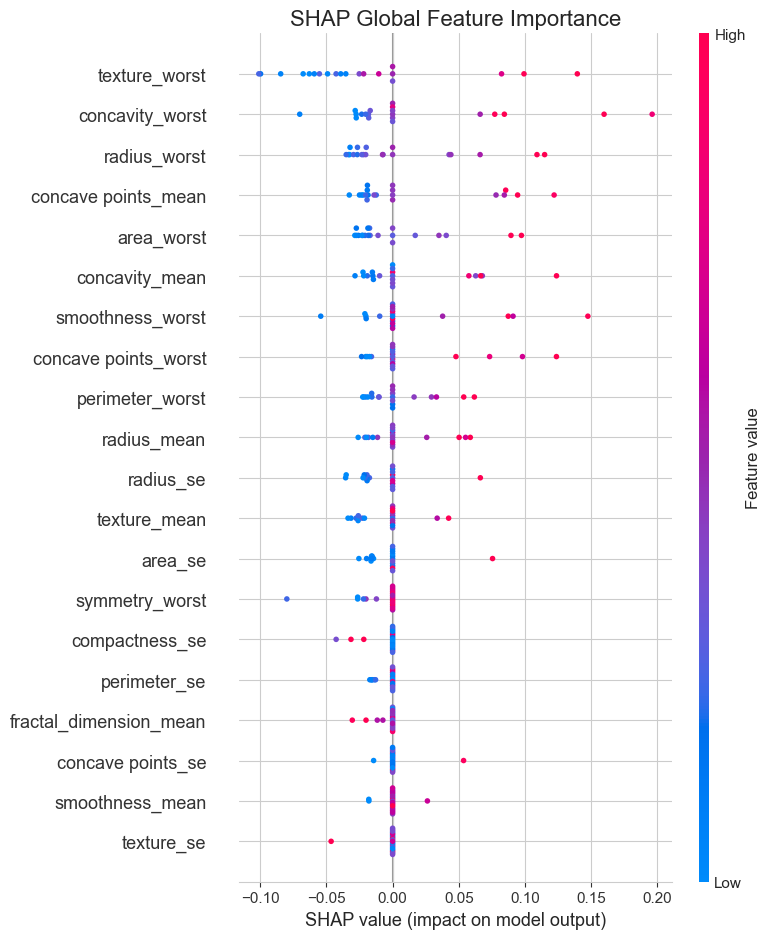


SHAP Local Explanation (Force Plot) for Test Sample 1:


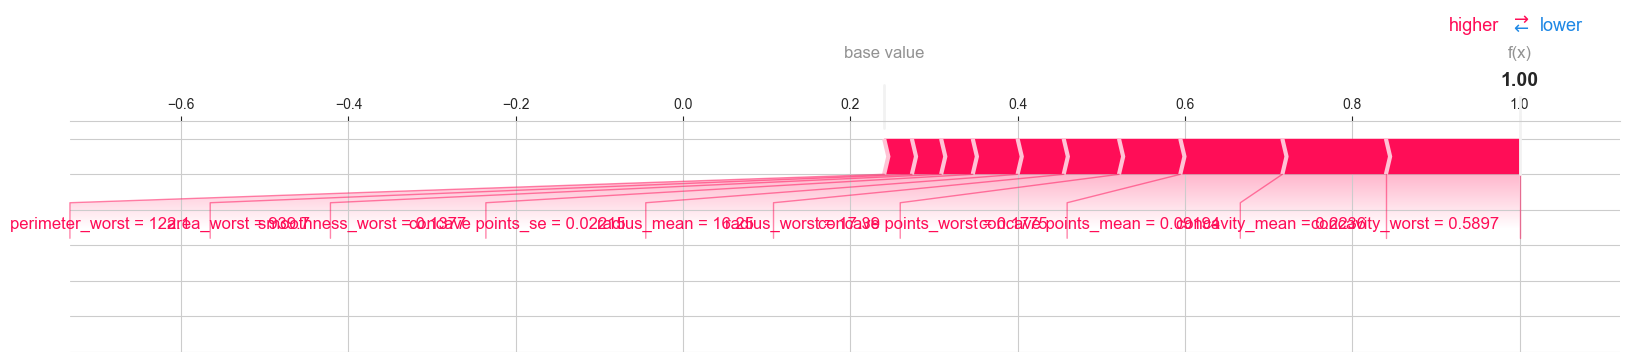

In [22]:
# Explainable AI (XAI) using SHAP for Keras Model 
print("\n--- Generating SHAP Explanations for Keras Deep Neural Network ---")

# 1. Define the wrapper function 
def keras_prediction_wrapper(x):
    return model.predict(x)[:, 0]

# 2. Setup Background Data
np.random.seed(42)
background_data = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 50, replace=False)]

# 3. Create Explainer
explainer = shap.KernelExplainer(keras_prediction_wrapper, background_data)

# 4. Calculate SHAP Values
print("Calculating SHAP values (this may take a few seconds)...")
shap_values = explainer.shap_values(X_test_scaled_df.iloc[:20].values) 
print("SHAP values calculated.")

# --- PLOT 1: SHAP Summary Plot (Global Importance) ---
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled_df.iloc[:20].values, feature_names=X.columns, show=False)
plt.title("SHAP Global Feature Importance", fontsize=16)
plt.tight_layout()
plt.show()

# --- PLOT 2: SHAP Force Plot (Local Explanation) ---
print("\nSHAP Local Explanation (Force Plot) for Test Sample 1:")

# use matplotlib=True to ensure it renders inside the notebook output.
p = shap.force_plot(explainer.expected_value, shap_values[10],
                     X_test.iloc[10], feature_names=X.columns, show=False, matplotlib=True)
plt.show(p)

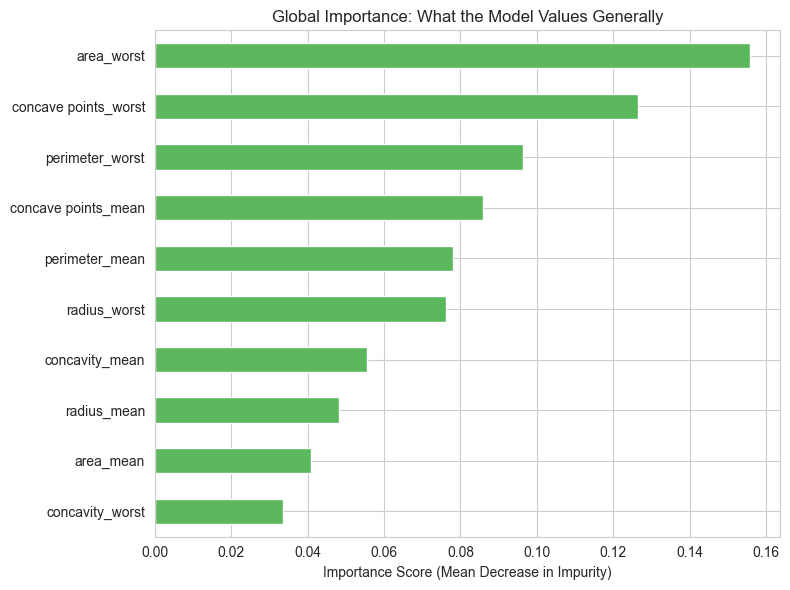

Generating Local Attribution for Patient Index 10...


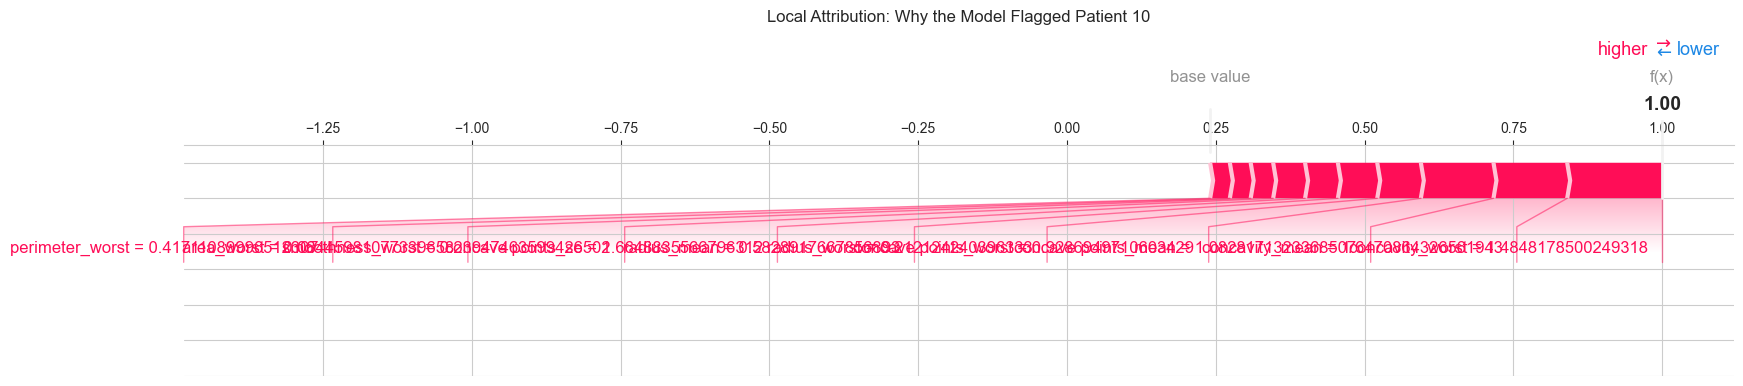

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import shap

# --- PLOT 1: Global Feature Importance (The "General Rule") ---
plt.figure(figsize=(8, 6))
# Get top 10 features from your Random Forest (rf)
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='#5cb85c')
plt.title('Global Importance: What the Model Values Generally')
plt.xlabel('Importance Score (Mean Decrease in Impurity)')
plt.tight_layout()
plt.savefig('global_importance.png', dpi=300)
plt.show()

# --- PLOT 2: Local Feature Attribution (The "Patient Case") ---
# We use Row 10 because it's your 'Safety Case'
test_row = 10 
print(f"Generating Local Attribution for Patient Index {test_row}...")

# Use matplotlib=True to render as a static image for your report
shap.force_plot(
    explainer.expected_value, 
    shap_values[test_row], 
    X_test_scaled_df.iloc[test_row], 
    feature_names=X.columns, 
    matplotlib=True, 
    show=False
)
plt.title(f'Local Attribution: Why the Model Flagged Patient {test_row}', y=1.5)
plt.savefig('local_attribution_row10.png', dpi=300, bbox_inches='tight')
plt.show()

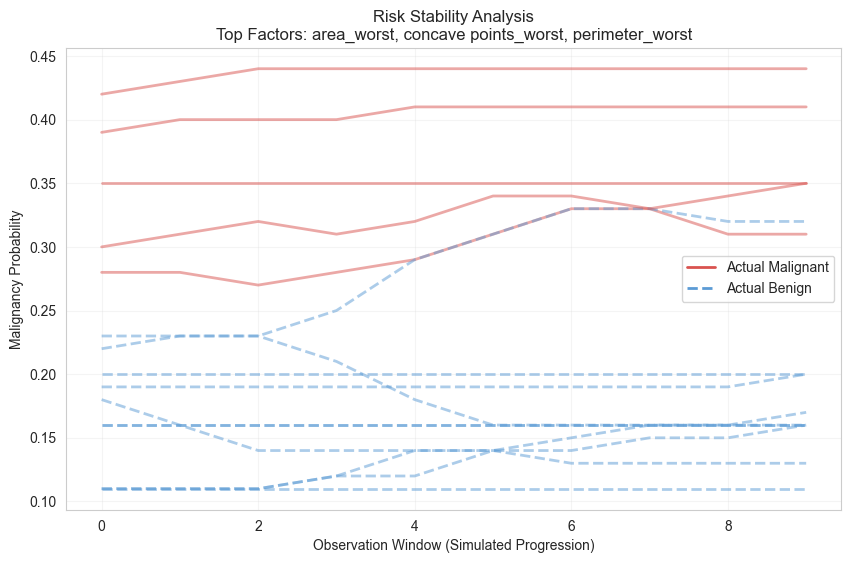

In [24]:
# --- Risk Progression Analysis (Appendix) ---

# 1. Calculate Feature Importance from your 'rf' model
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
key_feats = feat_importances.nlargest(5).index.tolist()

# 2. Generate Pseudo-Time Data
risk_curves = []
for i in range(min(len(X_test_scaled_df), 15)): # Analyze first 15 test samples
    row = X_test_scaled_df.iloc[[i]].copy()
    probs = []
    # Create 10 steps of data variation (+/- 20%) to simulate progression
    for step in np.linspace(0.8, 1.2, 10): 
        temp_row = row * step
        probs.append(rf.predict_proba(temp_row)[0][1])
    risk_curves.append({"proba": probs, "y_true": y_test.iloc[i]})

# 3. Plotting the Risk Curves
plt.figure(figsize=(10, 6))

for rc in risk_curves:
    # Red solid lines for actual cancer cases, Blue dashed for benign
    line_style = '-' if rc["y_true"] == 1 else '--'
    color = '#d9534f' if rc["y_true"] == 1 else '#5b9bd5'
    
    plt.plot(range(len(rc["proba"])), rc["proba"], 
             linestyle=line_style, color=color, alpha=0.5, linewidth=2)

plt.xlabel("Observation Window (Simulated Progression)")
plt.ylabel("Malignancy Probability")
plt.title(f"Risk Stability Analysis\nTop Factors: {', '.join(key_feats[:3])}")

# Custom Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='#d9534f', lw=2, label='Actual Malignant'),
                   Line2D([0], [0], color='#5b9bd5', lw=2, linestyle='--', label='Actual Benign')]
plt.legend(handles=legend_elements, loc='best')

plt.grid(True, alpha=0.2)
plt.show()

In [25]:
# Try row 5 or row 10 instead of row 0
test_row = 10 
another_sample = X_test_scaled_df.iloc[[test_row]]
new_proba = rf.predict_proba(another_sample)[0]

print(f"Row {test_row} Probability - Benign: {new_proba[0]*100:.1f}%, Malignant: {new_proba[1]*100:.1f}%")

Row 10 Probability - Benign: 65.0%, Malignant: 35.0%


In [26]:
# Check the actual labels for the two rows you tested
print(f"Row 0 (99% Benign) - Actual Label: {y_test.iloc[0]}")
print(f"Row 10 (57% Benign) - Actual Label: {y_test.iloc[10]}")

# Note: 0 is usually Benign, 1 is Malignant

Row 0 (99% Benign) - Actual Label: 0
Row 10 (57% Benign) - Actual Label: 1


In [27]:
# Instead of picking the highest number, let's be "Conservative"
# If Malignant probability is > 30%, we flag it for review
if malignant_percent > 30:
    print("Result: Flagged for further Medical Review (Suspicious)")
else:
    print("Result: Likely Benign")

Result: Flagged for further Medical Review (Suspicious)
